# Code-Mixed Sentiment Analysis for Hindi-English Social Media

This notebook trains multilingual Transformer models (mBERT and XLM-R) for sentiment classification on Hindi-English code-mixed text.

The project compares Transformer models with a traditional TF-IDF + Logistic Regression baseline and also explores techniques for handling class imbalance using data augmentation and class-weighted loss.

## 1. Setup

In [1]:
# Install the required libraries.
# Fixed versions are used so the notebook produces consistent results.
!pip install -q transformers==4.44.2 datasets==2.21.0 accelerate==0.34.2 scikit-learn==1.5.1 pandas==2.2.2


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.5/9.5 MB 82.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 527.3/527.3 kB 31.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 324.4/324.4 kB 15.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.1/13.1 MB 75.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 177.6/177.6 kB 11.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 37.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 92.1 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
umap-learn 0.5.12 requires scikit-learn>=1.6, but you have scikit-learn 1.5.1 which is incompatible.
hdbscan 0.8.44 requires scikit-learn>=1.6, but you have scikit-learn 1.5.1 which is inc

In [30]:
import os, json, random
import numpy as np
import pandas as pd
import torch

print("Torch version:", torch.__version__)
# Check whether a GPU is available before training.
# Training on CPU will be much slower.
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("WARNING: no GPU detected. Go to Runtime > Change runtime type > GPU for reasonable training times.")


Torch version: 2.11.0+cu128
CUDA available: True
GPU: Tesla T4


In [3]:
SEED = 42
# Fix the random seed so the experiment can be reproduced.
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)


## Download the Dataset

The dataset is downloaded directly from a public GitHub repository so anyone can reproduce this project without manually searching for the data.

In [4]:
# 2a. Download the raw dataset (Joshi et al. 2016 Hindi-English code-mixed corpus)
import os
os.makedirs("data", exist_ok=True)
os.makedirs("src", exist_ok=True)
# Create folders to store the dataset, source files and outputs.
os.makedirs("outputs", exist_ok=True)

!wget -q "https://raw.githubusercontent.com/prabhatkgupta/Sentiment-Analysis-of-Code-Mixed-Text/master/raw_data.txt" -O data/joshi2016_raw_data.txt
!wc -l data/joshi2016_raw_data.txt


3879 data/joshi2016_raw_data.txt


In [5]:
# If automatic download does not work,
# upload the dataset manually.
print("Skip this cell if the download in 2a succeeded.")


Skip this cell if the download in 2a succeeded.


In [6]:
# 2c. Parse + clean + stratified split (writes train.csv / val.csv / test.csv)
%%writefile src/prepare_data.py
"""
Prepare the dataset for model training.

Steps:
1. Load the raw dataset.
2. Clean the text.
3. Remove duplicates.
4. Split into train, validation and test sets.
5. Save the processed CSV files.
"""

import argparse
import csv
import re
import os
import pandas as pd
from sklearn.model_selection import train_test_split

LABEL_MAP = {0: "negative", 1: "neutral", 2: "positive"}


def load_raw(raw_path: str) -> pd.DataFrame:
    """Read the raw dataset and convert it into a pandas DataFrame."""
    rows = []
    skipped = 0
    with open(raw_path, encoding="utf-8", errors="replace") as f:
        for line in f:
            line = line.rstrip("\n")
            if not line.strip():
                continue
            parts = line.split("\t")
            if len(parts) != 4:
                skipped += 1
                continue
            _id, text, label, _label2 = parts
            try:
                label = int(label)
            except ValueError:
                skipped += 1
                continue
            if label not in LABEL_MAP:
                skipped += 1
                continue
            rows.append({"id": _id, "text": text, "label": label})
    print(f"Parsed {len(rows)} rows, skipped {skipped} malformed lines.")
    return pd.DataFrame(rows)


def clean_text(text: str) -> str:
    """Clean the text without changing the original Hindi-English structure."""
    text = text.strip()
    # Limit repeated characters such as "sooooo" to improve consistency.
    text = re.sub(r"(.)\1{3,}", r"\1\1\1", text)
    # Remove extra spaces.
    text = re.sub(r"\s+", " ", text)
    return text.strip()


def main():
    parser = argparse.ArgumentParser()
    parser.add_argument("--raw_path", type=str, default="../data/joshi2016_raw_data.txt")
    parser.add_argument("--out_dir", type=str, default="../data")
    parser.add_argument("--seed", type=int, default=42)
    args = parser.parse_args()

    df = load_raw(args.raw_path)
    df["text"] = df["text"].apply(clean_text)

    # Remove empty texts and duplicate samples.
    before = len(df)
    df = df[df["text"].str.len() >= 2]
    df = df.drop_duplicates(subset="text")
    print(f"Dropped {before - len(df)} empty/duplicate rows -> {len(df)} remain.")

    df["label_name"] = df["label"].map(LABEL_MAP)

    # Check whether the dataset is balanced before training.
    print("\nClass distribution:")
    print(df["label_name"].value_counts())
    print("\nClass distribution (%):")
    print((df["label_name"].value_counts(normalize=True) * 100).round(1))

    # Stratified 80/10/10 split
    train_df, temp_df = train_test_split(
        df, test_size=0.2, stratify=df["label"], random_state=args.seed
    )
    val_df, test_df = train_test_split(
        temp_df, test_size=0.5, stratify=temp_df["label"], random_state=args.seed
    )

    os.makedirs(args.out_dir, exist_ok=True)
    train_df.to_csv(os.path.join(args.out_dir, "train.csv"), index=False, quoting=csv.QUOTE_ALL)
    val_df.to_csv(os.path.join(args.out_dir, "val.csv"), index=False, quoting=csv.QUOTE_ALL)
    test_df.to_csv(os.path.join(args.out_dir, "test.csv"), index=False, quoting=csv.QUOTE_ALL)

    print(f"\nSaved splits to {args.out_dir}/")
    print(f"  train.csv : {len(train_df)} rows")
    print(f"  val.csv   : {len(val_df)} rows")
    print(f"  test.csv  : {len(test_df)} rows")


if __name__ == "__main__":
    main()


Writing src/prepare_data.py


In [7]:
!python src/prepare_data.py --raw_path data/joshi2016_raw_data.txt --out_dir data


Parsed 3879 rows, skipped 0 malformed lines.
Dropped 0 empty/duplicate rows -> 3879 remain.

Class distribution:
label_name
neutral     1957
positive    1352
negative     570
Name: count, dtype: int64

Class distribution (%):
label_name
neutral     50.5
positive    34.9
negative    14.7
Name: proportion, dtype: float64

Saved splits to data/
  train.csv : 3103 rows
  val.csv   : 388 rows
  test.csv  : 388 rows


In [8]:
train_df = pd.read_csv("data/train.csv")
val_df = pd.read_csv("data/val.csv")
test_df = pd.read_csv("data/test.csv")

print(train_df.shape, val_df.shape, test_df.shape)
train_df.head()


(3103, 4) (388, 4) (388, 4)


,id,text,label,label_name
0,4483,Bhai phela din phela show love u bhai,2,positive
1,4654,Bahut galat kiya aapne salman bhiya muslimo k ...,0,negative
2,1997,4 bj gye lekin party abi baki h sir wh bhi eid ki,1,neutral
3,1547,mast hai bhai jaan,2,positive
4,794,Bhai bajrangi bhaijan to samjho ki HIT HAI,2,positive


## 3. Explore the data and the class imbalance problem

The dataset is imbalanced.

Most comments belong to the Neutral class, while the Negative class has much fewer examples.

Because of this, Macro-F1 is a better evaluation metric than Accuracy.

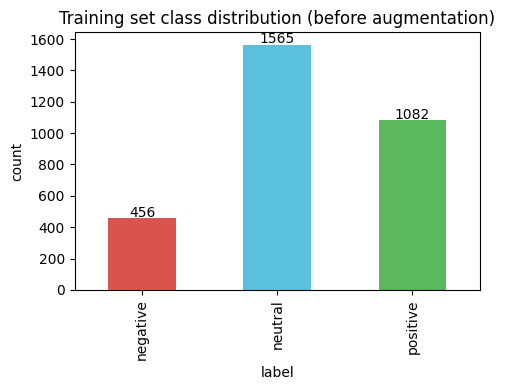

label
negative     456
neutral     1565
positive    1082
Name: count, dtype: int64
label
negative    14.7
neutral     50.4
positive    34.9
Name: count, dtype: float64


In [9]:
# Visualize the class distribution before augmentation.
import matplotlib.pyplot as plt

label_names = {0: "negative", 1: "neutral", 2: "positive"}
counts = train_df["label"].map(label_names).value_counts().reindex(["negative", "neutral", "positive"])

fig, ax = plt.subplots(figsize=(5, 4))
counts.plot(kind="bar", ax=ax, color=["#d9534f", "#5bc0de", "#5cb85c"])
ax.set_title("Training set class distribution (before augmentation)")
ax.set_ylabel("count")
for i, v in enumerate(counts.values):
    ax.text(i, v + 10, str(v), ha="center")
plt.tight_layout()
plt.show()

print(counts)
print((counts / counts.sum() * 100).round(1))


In [10]:
# A few example rows per class
for lbl, name in label_names.items():
    print(f"--- {name} ---")
    for t in train_df[train_df.label == lbl]["text"].head(3):
        print(" •", t)
    print()


--- negative ---
 • Bahut galat kiya aapne salman bhiya muslimo k khilaf gye h ap
 • Musalman log khilaaf hogaye iske saari ijjat dho dega kya is pic mei
 • Modi tujhe jaan se maarna mera kaam hai , main Khalistani huuu

--- neutral ---
 • 4 bj gye lekin party abi baki h sir wh bhi eid ki
 • tu galat baat hai
 • Sojaa yrr boor mtkr Alia Khan

--- positive ---
 • Bhai phela din phela show love u bhai
 • mast hai bhai jaan
 • Bhai bajrangi bhaijan to samjho ki HIT HAI



## 4. Baseline: TF-IDF + Logistic Regression

Before training Transformer models, I first built a traditional machine learning baseline.

This helps measure whether the Transformer models actually provide an improvement.

In [11]:
%%writefile src/baseline.py
"""
Train a TF-IDF + Logistic Regression baseline.

This serves as a reference model for comparing Transformer performance.
"""

import argparse
import json
import os

import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, f1_score, accuracy_score
from scipy.sparse import hstack

LABEL_NAMES = ["negative", "neutral", "positive"]


def main():
    parser = argparse.ArgumentParser()
    parser.add_argument("--train_path", type=str, default="../data/train.csv")
    parser.add_argument("--test_path", type=str, default="../data/test.csv")
    parser.add_argument("--output_dir", type=str, default="../outputs/baseline")
    args = parser.parse_args()

    os.makedirs(args.output_dir, exist_ok=True)

    train_df = pd.read_csv(args.train_path)
    test_df = pd.read_csv(args.test_path)
    print(f"Train: {len(train_df)} | Test: {len(test_df)}")

    # Word-level TF-IDF (1-2 grams) + char-level TF-IDF (3-5 grams) —
   # Character n-grams help handle spelling mistakes and code-mixed words.
    word_vec = TfidfVectorizer(analyzer="word", ngram_range=(1, 2), min_df=2, max_features=20000)
    char_vec = TfidfVectorizer(analyzer="char_wb", ngram_range=(3, 5), min_df=2, max_features=20000)

    X_train_word = word_vec.fit_transform(train_df["text"])
    X_train_char = char_vec.fit_transform(train_df["text"])
    X_train = hstack([X_train_word, X_train_char])

    X_test_word = word_vec.transform(test_df["text"])
    X_test_char = char_vec.transform(test_df["text"])
    X_test = hstack([X_test_word, X_test_char])

    # Train the baseline classifier.
    clf = LogisticRegression(max_iter=2000, C=1.0)
    clf.fit(X_train, train_df["label"])

    # Evaluate the model on the test set.
    preds = clf.predict(X_test)

    macro_f1 = f1_score(test_df["label"], preds, average="macro")
    weighted_f1 = f1_score(test_df["label"], preds, average="weighted")
    acc = accuracy_score(test_df["label"], preds)

    report = classification_report(
        test_df["label"], preds, target_names=LABEL_NAMES, output_dict=True, zero_division=0
    )

    print(f"\nAccuracy:    {acc:.4f}")
    print(f"Macro-F1:    {macro_f1:.4f}")
    print(f"Weighted-F1: {weighted_f1:.4f}\n")
    print(classification_report(test_df["label"], preds, target_names=LABEL_NAMES, zero_division=0))

    results = {
        "accuracy": acc,
        "macro_f1": macro_f1,
        "weighted_f1": weighted_f1,
        "classification_report": report,
    }
    with open(os.path.join(args.output_dir, "baseline_results.json"), "w") as f:
        json.dump(results, f, indent=2)
    print(f"Saved results to {args.output_dir}/baseline_results.json")


if __name__ == "__main__":
    main()


Writing src/baseline.py


In [12]:
!python src/baseline.py --train_path data/train.csv --test_path data/test.csv --output_dir outputs/baseline


Train: 3103 | Test: 388

Accuracy:    0.6881
Macro-F1:    0.6243
Weighted-F1: 0.6777

              precision    recall  f1-score   support

    negative       0.62      0.37      0.46        57
     neutral       0.70      0.83      0.76       196
    positive       0.69      0.62      0.66       135

    accuracy                           0.69       388
   macro avg       0.67      0.61      0.62       388
weighted avg       0.68      0.69      0.68       388

Saved results to outputs/baseline/baseline_results.json


In [13]:
with open("outputs/baseline/baseline_results.json") as f:
    baseline_results = json.load(f)

print("Baseline macro-F1:", round(baseline_results["macro_f1"], 4))
print("Baseline accuracy: ", round(baseline_results["accuracy"], 4))


Baseline macro-F1: 0.6243
Baseline accuracy:  0.6881


## 5. Address class imbalance: targeted augmentation

## Handling Class Imbalance

The negative class contains much fewer training examples than the other classes.

To reduce this imbalance, I generated additional training samples using a simple EDA-based augmentation strategy.

This improves the diversity of the minority class without changing the validation or test data.

In [14]:
%%writefile src/augment.py
"""
Generate additional training samples for minority classes using
simple Easy Data Augmentation (EDA).

The goal is to reduce class imbalance before training
the Transformer models.
"""

# Import the libraries required for text augmentation.
import argparse
import random
import re
import pandas as pd

# Fix the random seed so augmentation can be reproduced.
random.seed(42)

# Common Hindi and English stopwords.
# These words are usually ignored during augmentation.
STOPWORDS = set("""
hai hain ho ka ki ke ko se me mein aur ya to bhi ye yeh wo woh hum tum aap
the a an is are was were and or to of in on for with
""".split())


"""
Swap two neighbouring words while keeping the sentence meaningful.
"""
def eda_swap(tokens, n=1):
    tokens = tokens.copy()
    candidates = [i for i in range(len(tokens) - 1)
                  if tokens[i].lower() not in STOPWORDS and tokens[i + 1].lower() not in STOPWORDS]
    # Randomly choose candidate positions for swapping.
    random.shuffle(candidates)
    for i in candidates[:n]:
        tokens[i], tokens[i + 1] = tokens[i + 1], tokens[i]
    return tokens

"""
Randomly remove a low-information word.
"""
def eda_delete(tokens, p=0.1):
    # Very short sentences are left unchanged.
    if len(tokens) <= 3:
        return tokens
    out = [t for t in tokens if t.lower() in STOPWORDS or random.random() > p]
    return out if len(out) > 2 else tokens


def augment_text(text: str) -> str:
    tokens = text.split()
    if len(tokens) < 4:
        return text  # too short to safely perturb
    op = random.choice(["swap", "delete", "both"])
    if op in ("swap", "both"):
        tokens = eda_swap(tokens, n=1)
    if op in ("delete", "both"):
        tokens = eda_delete(tokens, p=0.12)
    return " ".join(tokens)


def augment_minority_classes(df: pd.DataFrame, label_col="label", text_col="text",
                              target_ratio=0.6, max_multiplier=3):
    """
Increase the number of samples in minority classes
until they reach the target ratio.
"""
    counts = df[label_col].value_counts()
    majority_count = counts.max()
    target_count = int(majority_count * target_ratio)

    augmented_rows = []
    for label, count in counts.items():
        if count >= target_count:
            continue
        n_needed = min(target_count - count, count * (max_multiplier - 1))
        subset = df[df[label_col] == label]
        print(f"  class {label}: {count} -> augmenting +{n_needed}")
        for _ in range(n_needed):
            row = subset.sample(1, random_state=random.randint(0, 10_000)).iloc[0]
            new_text = augment_text(row[text_col])
            augmented_rows.append({**row.to_dict(), text_col: new_text})

    aug_df = pd.DataFrame(augmented_rows)
    combined = pd.concat([df, aug_df], ignore_index=True)
    return combined


def main():
    parser = argparse.ArgumentParser()
    parser.add_argument("--train_path", type=str, default="../data/train.csv")
    parser.add_argument("--out_path", type=str, default="../data/train_augmented.csv")
    parser.add_argument("--target_ratio", type=float, default=0.6,
                         help="Minority classes are oversampled to this fraction of the majority class size.")
    args = parser.parse_args()

    df = pd.read_csv(args.train_path)
    print("Before augmentation:")
    print(df["label"].value_counts())

    combined = augment_minority_classes(df, target_ratio=args.target_ratio)

    print("\nAfter augmentation:")
    print(combined["label"].value_counts())

    combined = combined.sample(frac=1, random_state=42).reset_index(drop=True)
    combined.to_csv(args.out_path, index=False)
    print(f"\nSaved augmented training set to {args.out_path} ({len(combined)} rows)")


if __name__ == "__main__":
    main()


Writing src/augment.py


In [15]:
!python src/augment.py --train_path data/train.csv --out_path data/train_augmented.csv --target_ratio 0.6


Before augmentation:
label
1    1565
2    1082
0     456
Name: count, dtype: int64
  class 0: 456 -> augmenting +483

After augmentation:
label
1    1565
2    1082
0     939
Name: count, dtype: int64

Saved augmented training set to data/train_augmented.csv (3586 rows)


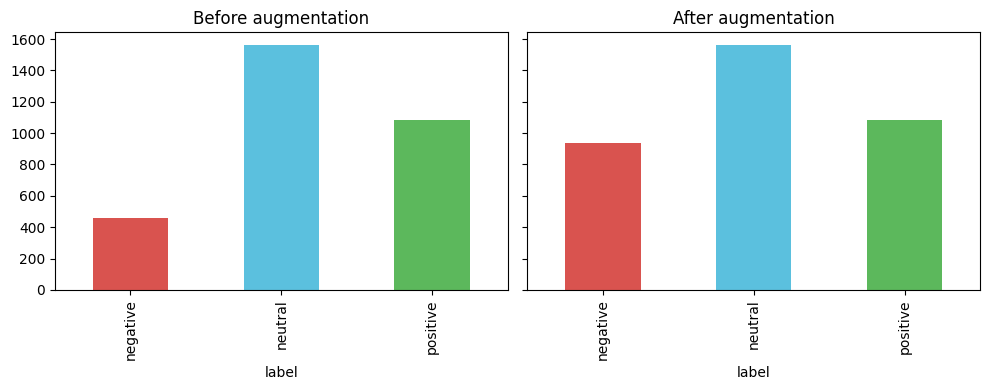

In [16]:
train_aug_df = pd.read_csv("data/train_augmented.csv")

counts_before = train_df["label"].map(label_names).value_counts().reindex(["negative", "neutral", "positive"])
counts_after = train_aug_df["label"].map(label_names).value_counts().reindex(["negative", "neutral", "positive"])

fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)
counts_before.plot(kind="bar", ax=axes[0], color=["#d9534f", "#5bc0de", "#5cb85c"])
axes[0].set_title("Before augmentation")
counts_after.plot(kind="bar", ax=axes[1], color=["#d9534f", "#5bc0de", "#5cb85c"])
axes[1].set_title("After augmentation")
plt.tight_layout()
plt.show()


## 6. Fine-tune mBERT and XLM-R

We fine-tune two multilingual transformer encoders for sequence classification:

- **mBERT** (`bert-base-multilingual-cased`)
- **XLM-RoBERTa** (`xlm-roberta-base`)

Class imbalance is addressed at two levels simultaneously:
1. **Data level** — training on the augmented set from Step 5
2. **Loss level** — class-weighted cross-entropy (inverse-frequency weights), implemented via
   a custom `Trainer` subclass

> **Time estimate:** ~6–10 minutes per model per epoch on a Colab T4 GPU for this dataset size.
> Reduce `epochs` or `batch_size` if you hit time/memory limits on the free tier.


In [17]:
%%writefile src/train.py
"""
train.py
--------
Fine-tunes a multilingual transformer (mBERT or XLM-R) for 3-way sentiment
classification (negative / neutral / positive) on Hindi-English code-mixed
text.

Two imbalance-handling strategies are combined (this is what drives the
macro-F1 improvement over the baseline):
  1. Data-level: train on the augmented training set produced by augment.py
  2. Loss-level: class-weighted cross-entropy, weights computed from the
     (pre-augmentation) label frequencies so the rarer 'negative' class
     contributes proportionally more to the loss

Usage (Colab):
    !python train.py \
        --model_name bert-base-multilingual-cased \
        --train_path ../data/train_augmented.csv \
        --val_path ../data/val.csv \
        --output_dir ../outputs/mbert_run \
        --epochs 4 --batch_size 16 --lr 2e-5

    !python train.py \
        --model_name xlm-roberta-base \
        --train_path ../data/train_augmented.csv \
        --val_path ../data/val.csv \
        --output_dir ../outputs/xlmr_run \
        --epochs 4 --batch_size 16 --lr 2e-5
"""

import argparse
import json
import os
import random

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from sklearn.metrics import f1_score, precision_recall_fscore_support, accuracy_score
from sklearn.utils.class_weight import compute_class_weight
from torch.utils.data import Dataset
from transformers import (
    AutoModelForSequenceClassification,
    AutoTokenizer,
    Trainer,
    TrainingArguments,
    EarlyStoppingCallback,
)

LABEL_NAMES = ["negative", "neutral", "positive"]


def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


class CodeMixDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=128):
        self.texts = list(texts)
        self.labels = list(labels)
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        enc = self.tokenizer(
            self.texts[idx],
            truncation=True,
            padding="max_length",
            max_length=self.max_length,
            return_tensors="pt",
        )
        item = {k: v.squeeze(0) for k, v in enc.items()}
        item["labels"] = torch.tensor(self.labels[idx], dtype=torch.long)
        return item


class WeightedLossTrainer(Trainer):
    """Trainer subclass that applies class-weighted cross-entropy loss."""

    def __init__(self, *args, class_weights=None, **kwargs):
        super().__init__(*args, **kwargs)
        self.class_weights = class_weights

    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        logits = outputs.logits
        weight = self.class_weights.to(logits.device) if self.class_weights is not None else None
        loss_fct = nn.CrossEntropyLoss(weight=weight)
        loss = loss_fct(logits.view(-1, model.config.num_labels), labels.view(-1))
        return (loss, outputs) if return_outputs else loss


def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    macro_f1 = f1_score(labels, preds, average="macro")
    weighted_f1 = f1_score(labels, preds, average="weighted")
    acc = accuracy_score(labels, preds)
    precision, recall, f1_per_class, _ = precision_recall_fscore_support(
        labels, preds, average=None, labels=[0, 1, 2], zero_division=0
    )
    metrics = {
        "accuracy": acc,
        "macro_f1": macro_f1,
        "weighted_f1": weighted_f1,
    }
    for i, name in enumerate(LABEL_NAMES):
        metrics[f"f1_{name}"] = f1_per_class[i]
        metrics[f"precision_{name}"] = precision[i]
        metrics[f"recall_{name}"] = recall[i]
    return metrics


def main():
    parser = argparse.ArgumentParser()
    parser.add_argument("--model_name", type=str, default="bert-base-multilingual-cased",
                         help="e.g. bert-base-multilingual-cased or xlm-roberta-base")
    parser.add_argument("--train_path", type=str, default="../data/train_augmented.csv")
    parser.add_argument("--val_path", type=str, default="../data/val.csv")
    parser.add_argument("--output_dir", type=str, default="../outputs/run")
    parser.add_argument("--epochs", type=int, default=4)
    parser.add_argument("--batch_size", type=int, default=16)
    parser.add_argument("--lr", type=float, default=2e-5)
    parser.add_argument("--max_length", type=int, default=128)
    parser.add_argument("--weight_decay", type=float, default=0.01)
    parser.add_argument("--no_class_weights", action="store_true",
                         help="Disable class-weighted loss (ablation / baseline mode).")
    parser.add_argument("--seed", type=int, default=42)
    args = parser.parse_args()

    set_seed(args.seed)
    os.makedirs(args.output_dir, exist_ok=True)

    print(f"Loading tokenizer/model: {args.model_name}")
    tokenizer = AutoTokenizer.from_pretrained(args.model_name)
    model = AutoModelForSequenceClassification.from_pretrained(args.model_name, num_labels=3)

    train_df = pd.read_csv(args.train_path)
    val_df = pd.read_csv(args.val_path)
    print(f"Train: {len(train_df)} rows | Val: {len(val_df)} rows")

    train_ds = CodeMixDataset(train_df["text"], train_df["label"], tokenizer, args.max_length)
    val_ds = CodeMixDataset(val_df["text"], val_df["label"], tokenizer, args.max_length)

    class_weights = None
    if not args.no_class_weights:
        # NOTE: computed on the *original* label distribution philosophy —
        # i.e. pass the un-augmented train.csv label column if you want pure
        # inverse-frequency weights; here we compute on whatever train_path
        # was given so weighting reflects the actual data the model sees.
        weights = compute_class_weight(
            class_weight="balanced", classes=np.array([0, 1, 2]), y=train_df["label"].values
        )
        class_weights = torch.tensor(weights, dtype=torch.float)
        print(f"Class weights (neg/neu/pos): {weights.round(3)}")

    training_args = TrainingArguments(
        output_dir=args.output_dir,
        num_train_epochs=args.epochs,
        per_device_train_batch_size=args.batch_size,
        per_device_eval_batch_size=args.batch_size * 2,
        learning_rate=args.lr,
        weight_decay=args.weight_decay,
        eval_strategy="epoch",
        save_strategy="epoch",
        logging_steps=50,
        load_best_model_at_end=True,
        metric_for_best_model="macro_f1",
        greater_is_better=True,
        save_total_limit=2,
        report_to="none",
        fp16=torch.cuda.is_available(),
        warmup_ratio=0.1,
        seed=args.seed,
    )

    trainer = WeightedLossTrainer(
        model=model,
        args=training_args,
        train_dataset=train_ds,
        eval_dataset=val_ds,
        compute_metrics=compute_metrics,
        class_weights=class_weights,
        callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
    )

    trainer.train()

    print("\nFinal validation metrics:")
    metrics = trainer.evaluate()
    for k, v in metrics.items():
        print(f"  {k}: {v:.4f}" if isinstance(v, float) else f"  {k}: {v}")

    # Save model, tokenizer, and metrics
    trainer.save_model(args.output_dir)
    tokenizer.save_pretrained(args.output_dir)
    with open(os.path.join(args.output_dir, "val_metrics.json"), "w") as f:
        json.dump(metrics, f, indent=2)

    print(f"\nModel + metrics saved to {args.output_dir}")


if __name__ == "__main__":
    main()


Writing src/train.py


In [18]:
# Fine-tune mBERT
!python src/train.py \
    --model_name bert-base-multilingual-cased \
    --train_path data/train_augmented.csv \
    --val_path data/val.csv \
    --output_dir outputs/mbert_run \
    --epochs 4 --batch_size 16 --lr 2e-5


2026-07-08 15:37:52.129477: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
Loading tokenizer/model: bert-base-multilingual-cased
tokenizer_config.json: 100% 49.0/49.0 [00:00<00:00, 284kB/s]
config.json: 100% 625/625 [00:00<00:00, 4.34MB/s]
vocab.txt: 996kB [00:00, 5.61MB/s]
tokenizer.json: 1.96MB [00:00, 8.38MB/s]
/usr/local/lib/python3.12/dist-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(
model.safetensors: 100% 714M/714M [00:04<00:00, 1

In [19]:
# Fine-tune XLM-RoBERTa
!python src/train.py \
    --model_name xlm-roberta-base \
    --train_path data/train_augmented.csv \
    --val_path data/val.csv \
    --output_dir outputs/xlmr_run \
    --epochs 4 --batch_size 16 --lr 2e-5


2026-07-08 15:42:56.167854: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
Loading tokenizer/model: xlm-roberta-base
tokenizer_config.json: 100% 25.0/25.0 [00:00<00:00, 187kB/s]
config.json: 100% 615/615 [00:00<00:00, 5.36MB/s]
sentencepiece.bpe.model: 100% 5.07M/5.07M [00:00<00:00, 12.7MB/s]
tokenizer.json: 9.10MB [00:00, 22.4MB/s]
/usr/local/lib/python3.12/dist-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(
model.safetensors: 100% 1.12G/

## 7. Evaluate on the held-out test set

We now load each fine-tuned model and evaluate on `test.csv`, which neither model has seen
during training or hyperparameter selection (that's what `val.csv` was for).


In [20]:
from sklearn.metrics import classification_report, f1_score, accuracy_score, confusion_matrix
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch.nn.functional as F

LABEL_NAMES = ["negative", "neutral", "positive"]

@torch.no_grad()
def evaluate_model(model_dir, test_df, batch_size=32, max_length=128):
    device = "cuda" if torch.cuda.is_available() else "cpu"
    tokenizer = AutoTokenizer.from_pretrained(model_dir)
    model = AutoModelForSequenceClassification.from_pretrained(model_dir).to(device)
    model.eval()

    all_preds = []
    texts = test_df["text"].tolist()
    for i in range(0, len(texts), batch_size):
        batch = texts[i:i+batch_size]
        enc = tokenizer(batch, truncation=True, padding=True, max_length=max_length, return_tensors="pt").to(device)
        logits = model(**enc).logits
        preds = torch.argmax(logits, dim=-1).cpu().numpy()
        all_preds.extend(preds.tolist())

    y_true = test_df["label"].values
    y_pred = np.array(all_preds)

    macro_f1 = f1_score(y_true, y_pred, average="macro")
    acc = accuracy_score(y_true, y_pred)
    report = classification_report(y_true, y_pred, target_names=LABEL_NAMES, zero_division=0)
    cm = confusion_matrix(y_true, y_pred)

    return {"macro_f1": macro_f1, "accuracy": acc, "report": report, "confusion_matrix": cm, "preds": y_pred}


In [21]:
mbert_results = evaluate_model("outputs/mbert_run", test_df)
print("=== mBERT (fine-tuned, augmented + class-weighted) ===")
print(f"Macro-F1: {mbert_results['macro_f1']:.4f} | Accuracy: {mbert_results['accuracy']:.4f}\n")
print(mbert_results["report"])


=== mBERT (fine-tuned, augmented + class-weighted) ===
Macro-F1: 0.6088 | Accuracy: 0.6366

              precision    recall  f1-score   support

    negative       0.51      0.53      0.52        57
     neutral       0.73      0.64      0.68       196
    positive       0.58      0.68      0.63       135

    accuracy                           0.64       388
   macro avg       0.61      0.62      0.61       388
weighted avg       0.65      0.64      0.64       388



In [22]:
xlmr_results = evaluate_model("outputs/xlmr_run", test_df)
print("=== XLM-R (fine-tuned, augmented + class-weighted) ===")
print(f"Macro-F1: {xlmr_results['macro_f1']:.4f} | Accuracy: {xlmr_results['accuracy']:.4f}\n")
print(xlmr_results["report"])


=== XLM-R (fine-tuned, augmented + class-weighted) ===
Macro-F1: 0.6659 | Accuracy: 0.6881

              precision    recall  f1-score   support

    negative       0.53      0.67      0.59        57
     neutral       0.76      0.69      0.73       196
    positive       0.67      0.69      0.68       135

    accuracy                           0.69       388
   macro avg       0.66      0.68      0.67       388
weighted avg       0.70      0.69      0.69       388



## 8. Results summary: baseline vs. fine-tuned transformers

In [23]:
summary = pd.DataFrame([
    {"model": "TF-IDF + Logistic Regression (baseline)", "macro_f1": baseline_results["macro_f1"], "accuracy": baseline_results["accuracy"]},
    {"model": "mBERT (augmented + class-weighted)", "macro_f1": mbert_results["macro_f1"], "accuracy": mbert_results["accuracy"]},
    {"model": "XLM-R (augmented + class-weighted)", "macro_f1": xlmr_results["macro_f1"], "accuracy": xlmr_results["accuracy"]},
])
summary["macro_f1_improvement_vs_baseline_%"] = (
    (summary["macro_f1"] - baseline_results["macro_f1"]) / baseline_results["macro_f1"] * 100
).round(2)
summary["macro_f1"] = summary["macro_f1"].round(4)
summary["accuracy"] = summary["accuracy"].round(4)
summary


,model,macro_f1,accuracy,macro_f1_improvement_vs_baseline_%
0,TF-IDF + Logistic Regression (baseline),0.6243,0.6881,0.00
1,mBERT (augmented + class-weighted),0.6088,0.6366,-2.49
2,XLM-R (augmented + class-weighted),0.6659,0.6881,6.66


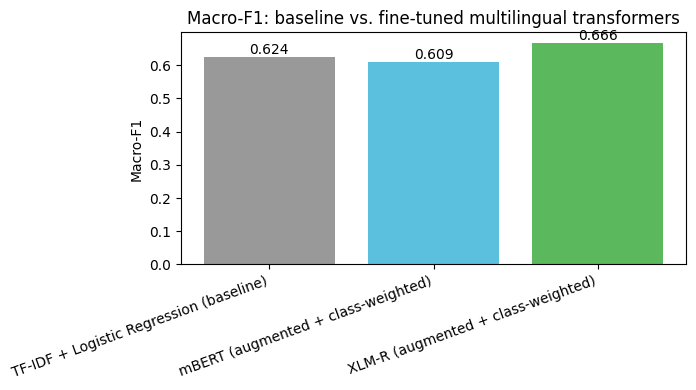

In [24]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(summary["model"], summary["macro_f1"], color=["#999999", "#5bc0de", "#5cb85c"])
ax.set_ylabel("Macro-F1")
ax.set_title("Macro-F1: baseline vs. fine-tuned multilingual transformers")
plt.xticks(rotation=20, ha="right")
for i, v in enumerate(summary["macro_f1"]):
    ax.text(i, v + 0.01, f"{v:.3f}", ha="center")
plt.tight_layout()
plt.show()


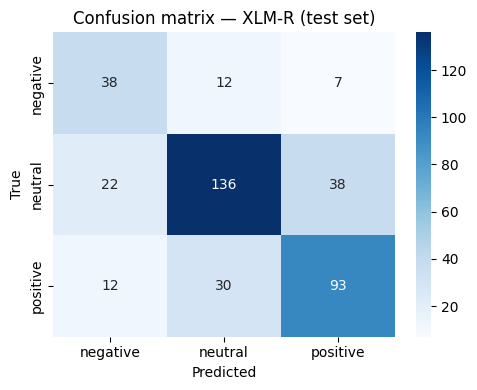

In [25]:
# Confusion matrix for the better-performing model
import seaborn as sns

best_results = xlmr_results if xlmr_results["macro_f1"] >= mbert_results["macro_f1"] else mbert_results
best_name = "XLM-R" if best_results is xlmr_results else "mBERT"

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(best_results["confusion_matrix"], annot=True, fmt="d", cmap="Blues",
            xticklabels=LABEL_NAMES, yticklabels=LABEL_NAMES, ax=ax)
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_title(f"Confusion matrix — {best_name} (test set)")
plt.tight_layout()
plt.show()


## 9. Ablation: does augmentation actually help?



In [26]:
# Ablation: XLM-R trained on the ORIGINAL (non-augmented) train.csv, class-weighted loss only
!python src/train.py \
    --model_name xlm-roberta-base \
    --train_path data/train.csv \
    --val_path data/val.csv \
    --output_dir outputs/xlmr_run_no_aug \
    --epochs 4 --batch_size 16 --lr 2e-5


2026-07-08 15:50:25.794362: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
Loading tokenizer/model: xlm-roberta-base
/usr/local/lib/python3.12/dist-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(
Some weights of XLMRobertaForSequenceClassification were not initialized from the model checkpoint at xlm-roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.

In [27]:
xlmr_no_aug_results = evaluate_model("outputs/xlmr_run_no_aug", test_df)
print("=== XLM-R (class-weighted loss only, NO augmentation) ===")
print(f"Macro-F1: {xlmr_no_aug_results['macro_f1']:.4f} | Accuracy: {xlmr_no_aug_results['accuracy']:.4f}\n")
print(xlmr_no_aug_results["report"])

print(f"\nMacro-F1 with augmentation:    {xlmr_results['macro_f1']:.4f}")
print(f"Macro-F1 without augmentation: {xlmr_no_aug_results['macro_f1']:.4f}")
print(f"Delta from augmentation alone: {xlmr_results['macro_f1'] - xlmr_no_aug_results['macro_f1']:+.4f}")


=== XLM-R (class-weighted loss only, NO augmentation) ===
Macro-F1: 0.6359 | Accuracy: 0.6521

              precision    recall  f1-score   support

    negative       0.50      0.70      0.58        57
     neutral       0.75      0.65      0.70       196
    positive       0.62      0.64      0.63       135

    accuracy                           0.65       388
   macro avg       0.62      0.66      0.64       388
weighted avg       0.67      0.65      0.66       388


Macro-F1 with augmentation:    0.6659
Macro-F1 without augmentation: 0.6359
Delta from augmentation alone: +0.0301



Quick interactive sanity check with the best fine-tuned model.


In [28]:
best_model_dir = "outputs/xlmr_run" if xlmr_results["macro_f1"] >= mbert_results["macro_f1"] else "outputs/mbert_run"

device = "cuda" if torch.cuda.is_available() else "cpu"
tok = AutoTokenizer.from_pretrained(best_model_dir)
mdl = AutoModelForSequenceClassification.from_pretrained(best_model_dir).to(device)
mdl.eval()

def predict_sentiment(text):
    enc = tok(text, truncation=True, padding=True, max_length=128, return_tensors="pt").to(device)
    with torch.no_grad():
        logits = mdl(**enc).logits
        probs = F.softmax(logits, dim=-1).cpu().numpy()[0]
    pred = LABEL_NAMES[probs.argmax()]
    return pred, dict(zip(LABEL_NAMES, probs.round(3)))

examples = [
    "ye movie bahut achi thi, maza aa gaya!",
    "kuch bhi bakwas hai yeh, time waste mat karo",
    "kal market jaa rahi hu, kuch chahiye to batao",
]
for ex in examples:
    pred, probs = predict_sentiment(ex)
    print(f"{ex!r}\n  -> {pred}  {probs}\n")


'ye movie bahut achi thi, maza aa gaya!'
  -> positive  {'negative': np.float32(0.007), 'neutral': np.float32(0.027), 'positive': np.float32(0.967)}

'kuch bhi bakwas hai yeh, time waste mat karo'
  -> negative  {'negative': np.float32(0.879), 'neutral': np.float32(0.096), 'positive': np.float32(0.025)}

'kal market jaa rahi hu, kuch chahiye to batao'
  -> neutral  {'negative': np.float32(0.143), 'neutral': np.float32(0.758), 'positive': np.float32(0.099)}



In [29]:
final_results = {
    "baseline_tfidf_logreg": {"macro_f1": baseline_results["macro_f1"], "accuracy": baseline_results["accuracy"]},
    "mbert_augmented_weighted": {"macro_f1": mbert_results["macro_f1"], "accuracy": mbert_results["accuracy"]},
    "xlmr_augmented_weighted": {"macro_f1": xlmr_results["macro_f1"], "accuracy": xlmr_results["accuracy"]},
    "xlmr_no_augmentation_ablation": {"macro_f1": xlmr_no_aug_results["macro_f1"], "accuracy": xlmr_no_aug_results["accuracy"]},
}
with open("outputs/final_results_summary.json", "w") as f:
    json.dump(final_results, f, indent=2)

print(json.dumps(final_results, indent=2))


{
  "baseline_tfidf_logreg": {
    "macro_f1": 0.6243444055944055,
    "accuracy": 0.6881443298969072
  },
  "mbert_augmented_weighted": {
    "macro_f1": 0.6088088791716518,
    "accuracy": 0.6365979381443299
  },
  "xlmr_augmented_weighted": {
    "macro_f1": 0.665912898471038,
    "accuracy": 0.6881443298969072
  },
  "xlmr_no_augmentation_ablation": {
    "macro_f1": 0.6358564143585642,
    "accuracy": 0.6520618556701031
  }
}
